In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import gc
gc.collect()

20

In [3]:
# 지수 -> 소수점(2) 표기
pd.options.display.float_format = '{:.2f}'.format

In [4]:
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [25]:
gc.collect()

8545

# 전체

In [6]:
chunk_iter = pd.read_csv("../Tableau/mart_total_final_oct.csv", chunksize=500000)
# chunk_iter = pd.read_csv("../Tableau/mart_total_final_nov.csv", chunksize=1000000)
chunks = []

for chunk in chunk_iter:
    chunks.append(chunk)
    
df = pd.concat(chunks, axis=0)

del chunks
gc.collect()

0

In [6]:
df.shape

(42418544, 50)

In [7]:
df.info

<bound method DataFrame.info of                    event_time event_type  product_id          category_id  \
0         2019-10-01 00:00:00       view    44600062  2103807459595387724   
1         2019-10-01 00:00:00       view     3900821  2053013552326770905   
2         2019-10-01 00:00:01       view    17200506  2053013559792632471   
3         2019-10-01 00:00:01       view     1307067  2053013558920217191   
4         2019-10-01 00:00:04       view     1004237  2053013555631882655   
...                       ...        ...         ...                  ...   
42418539  2019-10-31 23:59:58       view     2300275  2053013560530830019   
42418540  2019-10-31 23:59:58       view    10800172  2053013554994348409   
42418541  2019-10-31 23:59:58       view     5701038  2053013553970938175   
42418542  2019-10-31 23:59:59       view    21407424  2053013561579406073   
42418543  2019-10-31 23:59:59       view    13300120  2053013557166998015   

                                category_co

In [8]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session',
       'is_price_error', 'hour', 'day_of_week', 'day_name', 'time_segment',
       'is_outlier', 'view_yn', 'cart_yn', 'purchase_yn', 'brand_missing_yn',
       'is_price_error_yn', 'is_outlier_yn', 'event_date', 'event_month',
       'is_weekend', 'price_tier', 'total_spend', 'activity_days_count',
       'avg_view_per_purchase', 'brand_switcher_flag', 'session_duration_sec',
       'funnel_stage', 'is_view', 'is_cart', 'is_purchase',
       'time_to_purchase_sec', 'cart_retention_time', 'consider_purchase_tier',
       'decision_tier', 'view_sessions', 'view_to_cart_sessions',
       'cart_to_purchase_sessions', 'purchase_count', 'revenue', 'avg_price',
       'revenue_per_view', 'total_conversion_rate', 'view_to_cart_rate',
       'cart_to_purchase_rate', 'drop_view_to_cart', 'drop_cart_to_purchase'],
      dtype='str')

## 퍼널 분석 (2_전체)

- 메인 퍼널 전환 상관분석
- 단계별 병목 구간 특정 및 이탈 주요 영향 변수 탐색

In [9]:
df['funnel_stage'].unique()
df['funnel_stage'].value_counts()

funnel_stage
view        38087676
purchase     2994996
cart         1335872
Name: count, dtype: int64

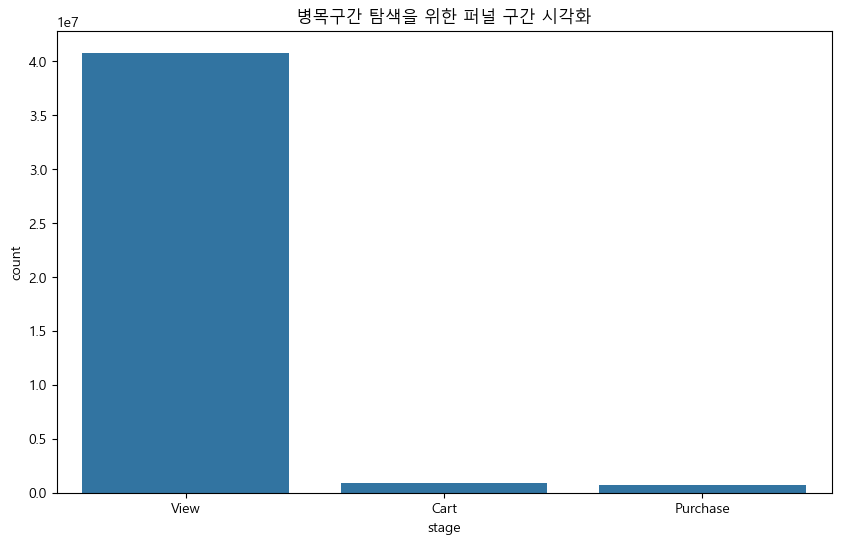

In [10]:
# 전체 유저 중 몇명이 다음 구간으로 넘어갔는가 

# funnel 구간
funnel = df[['view_yn', 'cart_yn', 'purchase_yn']].sum().reset_index()
funnel.columns = ['stage', 'count']
funnel['stage'] = ['View', 'Cart', 'Purchase']
funnel['cvr'] = (funnel['count'] / funnel['count'].shift(1) * 100).fillna(100)

plt.figure(figsize=(10, 6))
sns.barplot(data=funnel, x='stage', y='count')
plt.title('병목구간 탐색을 위한 퍼널 구간 시각화')
plt.show()

<Axes: >

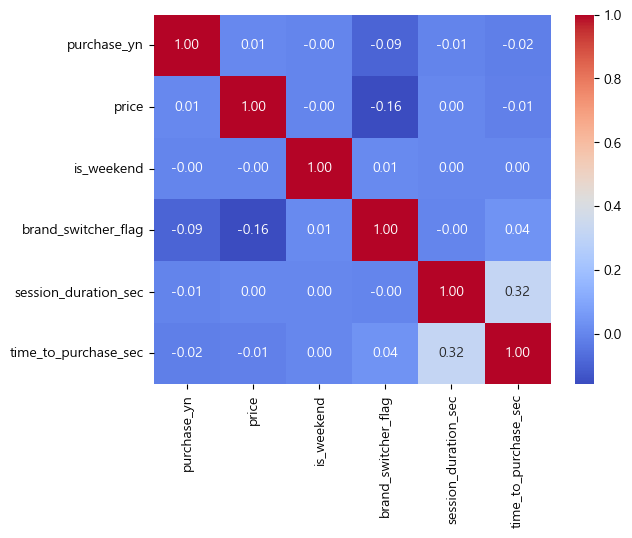

In [17]:
# 유저행동들 (특징)
cols = ['purchase_yn', 'price', 'is_weekend', 'brand_switcher_flag', 'session_duration_sec', 'time_to_purchase_sec']

# purchase_count : 총 주문/구매 건수 (price의 count)
# revenue : 총 매출액 (price의 sum)
# avg_price (SQL) : ‘브랜드 별’ 평균 상품 가격 → ROUND(AVG(price), 2) - 안 쓰기로 

# 구매 여부
# df['is_purchased'] = (df['purchase_yn'] > 0).astype(int)

sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
# 상관분석 (유저 기준 -total_spend)
# corr = df[['total_spend', 'total_views', 'total_carts', 'visit_weekend', 'is_purchased', 'purchase_count']].corr()
corr_col = ['total_spend', 'is_view', 'is_cart', 'is_weekend', 'is_purchase', 'purchase_count']

corr = df[corr_col].corr()

print(corr)

# 1. total_spend로 뭉개진 차원 감안하고 보기
# 2. 데이터 쪼개서 구한 price 개별 상위 / 하위 뽑은 것 사용
# 3. 가격 구간화 

                total_spend  is_view  is_cart  is_weekend  is_purchase  \
total_spend            1.00    -0.00     0.13       -0.00         0.20   
is_view               -0.00     1.00    -0.02       -0.00        -0.02   
is_cart                0.13    -0.02     1.00        0.01         0.50   
is_weekend            -0.00    -0.00     0.01        1.00         0.00   
is_purchase            0.20    -0.02     0.50        0.00         1.00   
purchase_count         0.08    -0.01     0.21       -0.00         0.14   

                purchase_count  
total_spend               0.08  
is_view                  -0.01  
is_cart                   0.21  
is_weekend               -0.00  
is_purchase               0.14  
purchase_count            1.00  


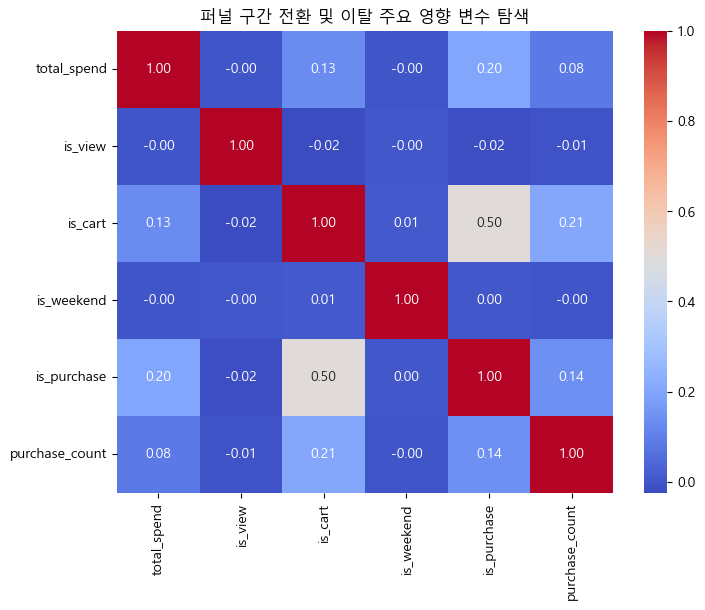

In [13]:
# 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('퍼널 구간 전환 및 이탈 주요 영향 변수 탐색')
plt.show()

- total_carts vs is_purchased : 어디서 빠져나가는가 (장바구니/구매)
    - 여기서 낮다 : 장바구니는 담는데 구매를 안 한다 (11월 프로모션과 연계할 가능성 有) (c-p의 병목구간)
- total_views vs is_purchased : 조회랑 구매의 관계 (이건 전처리 때 이미 본 거긴 한데) (조회/구매)
    - 낮다 : v -> p로 잘 안 이어진다 (v-c의 병목구간)
- 주말에 다녀감 : 이후 프로모션 기간이랑 대조해보면 또 인사이트 나올듯 / 예상 : 11월 블프 기간과 겹칠 것이다, 주말에는 소비가 클 것이다
- avg_price vs is_purchased : 가격/구매

- 배송이나 실제 상품 정보가 더 자세하게 나와있거나 유저 행동을 세부적으로 추측할 수 있게 수집된 데이터였으면 조금 더 볼 수 있었을 텐데 특히 배송 
- 단순 조회수랑 단순 장바구니에 담는 것만 본 거라 물론 메인 퍼널 기준이 세션+상품이라(실제 상품 기준)


- is_weekend는 태블로에서 확인했을 때 높았던 금~일 구간 확인하려고 넣었지만 유의미한 해석이 가능할 정도는 아닌듯

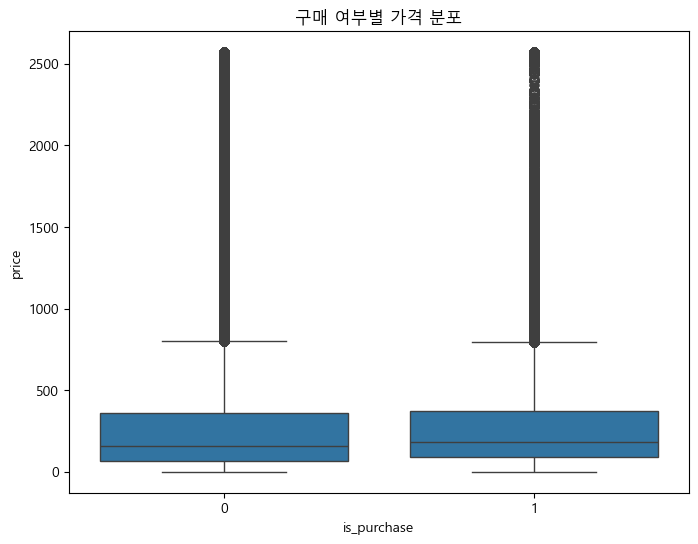

In [14]:
# 가격 차이

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_purchase', y='price')
plt.title('구매 여부별 가격 분포')
plt.show()

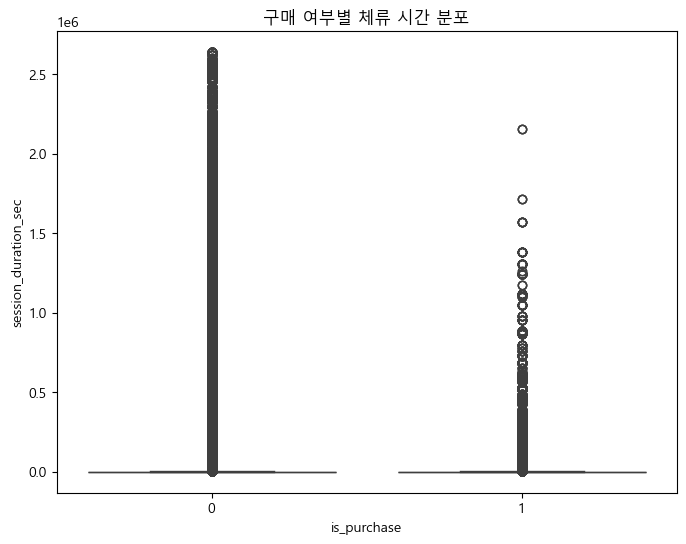

In [15]:
# 체류시간

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_purchase', y='session_duration_sec')
plt.title('구매 여부별 체류 시간 분포')
plt.show()

In [16]:
### SQL 데이터마트 파생변수 세부 탐색

                      purchase_yn  view_yn  cart_yn  price  hour  \
purchase_yn                  1.00    -0.67    -0.02   0.01 -0.02   
view_yn                     -0.67     1.00    -0.73  -0.02  0.03   
cart_yn                     -0.02    -0.73     1.00   0.02 -0.02   
price                        0.01    -0.02     0.02   1.00  0.02   
hour                        -0.02     0.03    -0.02   0.02  1.00   
time_to_purchase_sec        -0.02     0.02    -0.01  -0.01  0.00   
is_price_error_yn           -0.00    -0.00     0.00   0.67  0.01   
is_outlier_yn                0.07    -0.07     0.03   0.01 -0.00   

                      time_to_purchase_sec  is_price_error_yn  is_outlier_yn  
purchase_yn                          -0.02              -0.00           0.07  
view_yn                               0.02              -0.00          -0.07  
cart_yn                              -0.01               0.00           0.03  
price                                -0.01               0.67          

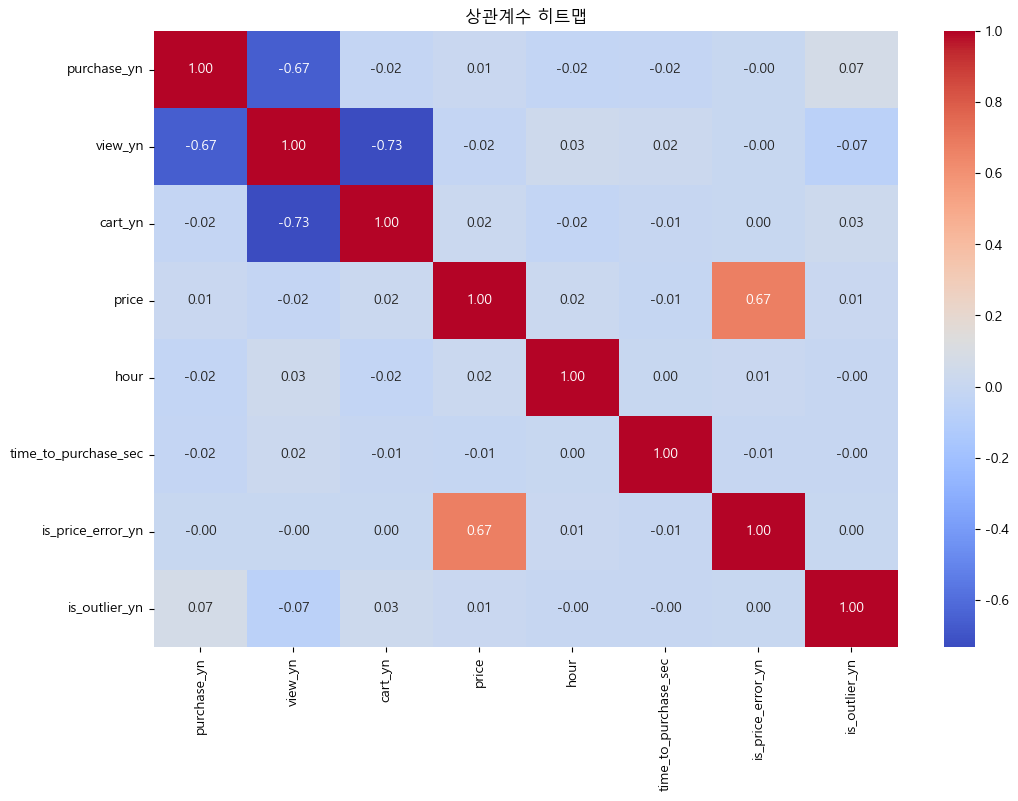

In [15]:
# 수치형 변수만 추출
corr_cols = [
    'purchase_yn', 'view_yn', 'cart_yn', 'price', 
    'hour', 'time_to_purchase_sec',
    'is_price_error_yn', 'is_outlier_yn'
]
corr = df[corr_cols].corr()
print(corr)

# 히트맵
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('상관계수 히트맵')
plt.show()

### decision_tier
- 구매 의사결정 시간 구간 분류(60초(1분)/5분/30분/1시간 기준)
- → ‘즉시 구매’의 세분화 

- consider_purchase_tier (즉시구매, 12, 24, 36, 36~)

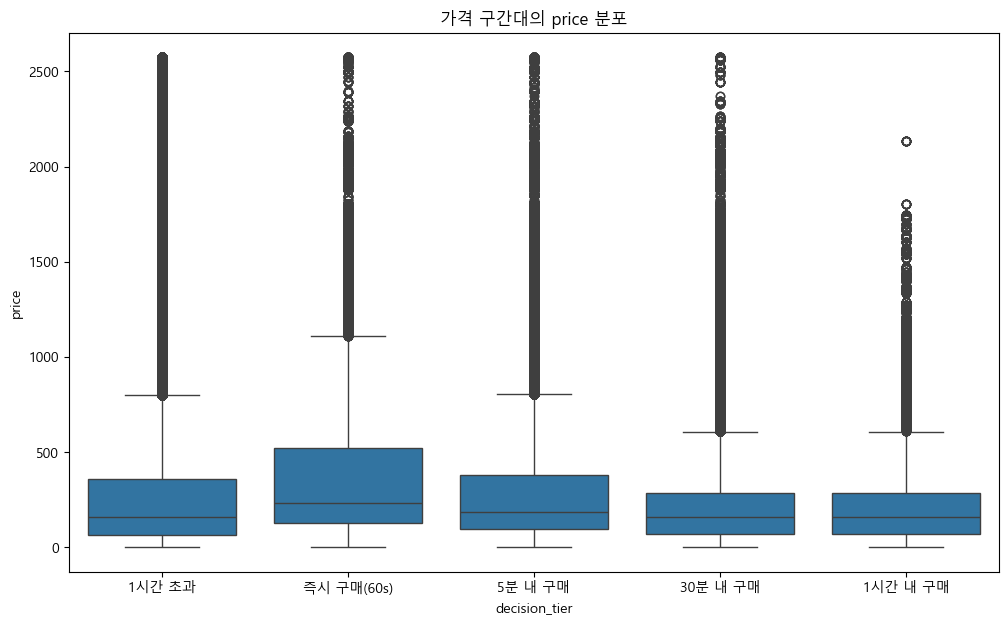

In [7]:
# decision_tier별 price 분포
### 가격 구간대의 price 분포에 따라 구매 고려 시간에 영향이 있는가 (60초(1분)/5분/30분/1시간 기준)

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='decision_tier', y='price')
plt.title('가격 구간대의 price 분포')
plt.ylabel('price')
plt.xlabel('decision_tier')
plt.show()

## consider_purchase_tier이랑도 보고 싶은데 그건 태블로로 보는 게 더 빠를 것 같다

### 병목 구간 세부 탐색(근거)

                      purchase_yn  price  brand_switcher_flag  \
purchase_yn                  1.00   0.01                -0.09   
price                        0.01   1.00                -0.16   
brand_switcher_flag         -0.09  -0.16                 1.00   
session_duration_sec        -0.01   0.00                -0.00   
time_to_purchase_sec        -0.02  -0.01                 0.04   

                      session_duration_sec  time_to_purchase_sec  
purchase_yn                          -0.01                 -0.02  
price                                 0.00                 -0.01  
brand_switcher_flag                  -0.00                  0.04  
session_duration_sec                  1.00                  0.32  
time_to_purchase_sec                  0.32                  1.00  


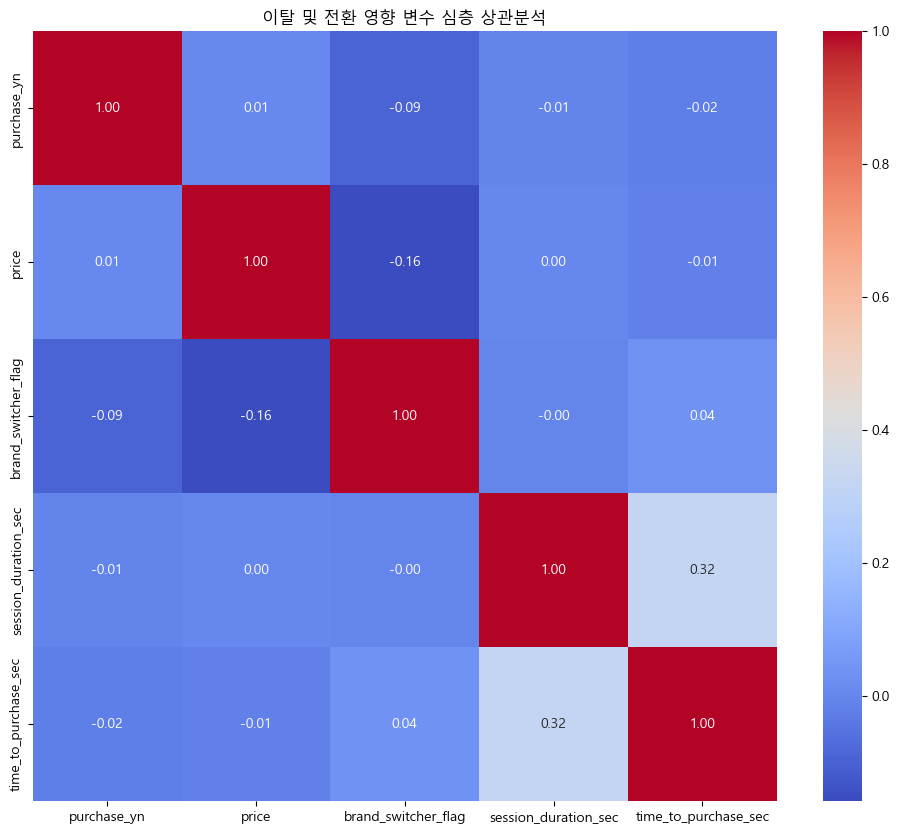

In [8]:
# 이탈 및 전환 주요 영향 변수 상관분석
corr_cols = [
    'purchase_yn', 'price', 
    'brand_switcher_flag', 'session_duration_sec',
    'time_to_purchase_sec' # v -> p 고민 시간
]
corr_data = df[corr_cols].corr()

print(corr_data)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('이탈 및 전환 영향 변수 심층 상관분석')
plt.show()


### SQL / python으로 만든 전환율 지표가 세션 기준이라 (total_conversion_rate라던가)

                           purchase_yn  view_sessions  session_duration_sec  \
purchase_yn                       1.00           0.06                 -0.03   
view_sessions                     0.06           1.00                 -0.13   
session_duration_sec             -0.03          -0.13                  1.00   
view_to_cart_sessions             0.06           0.92                 -0.12   
cart_to_purchase_sessions         0.07           0.99                 -0.13   
revenue                           0.06           0.96                 -0.14   

                           view_to_cart_sessions  cart_to_purchase_sessions  \
purchase_yn                                 0.06                       0.07   
view_sessions                               0.92                       0.99   
session_duration_sec                       -0.12                      -0.13   
view_to_cart_sessions                       1.00                       0.94   
cart_to_purchase_sessions                   0.94   

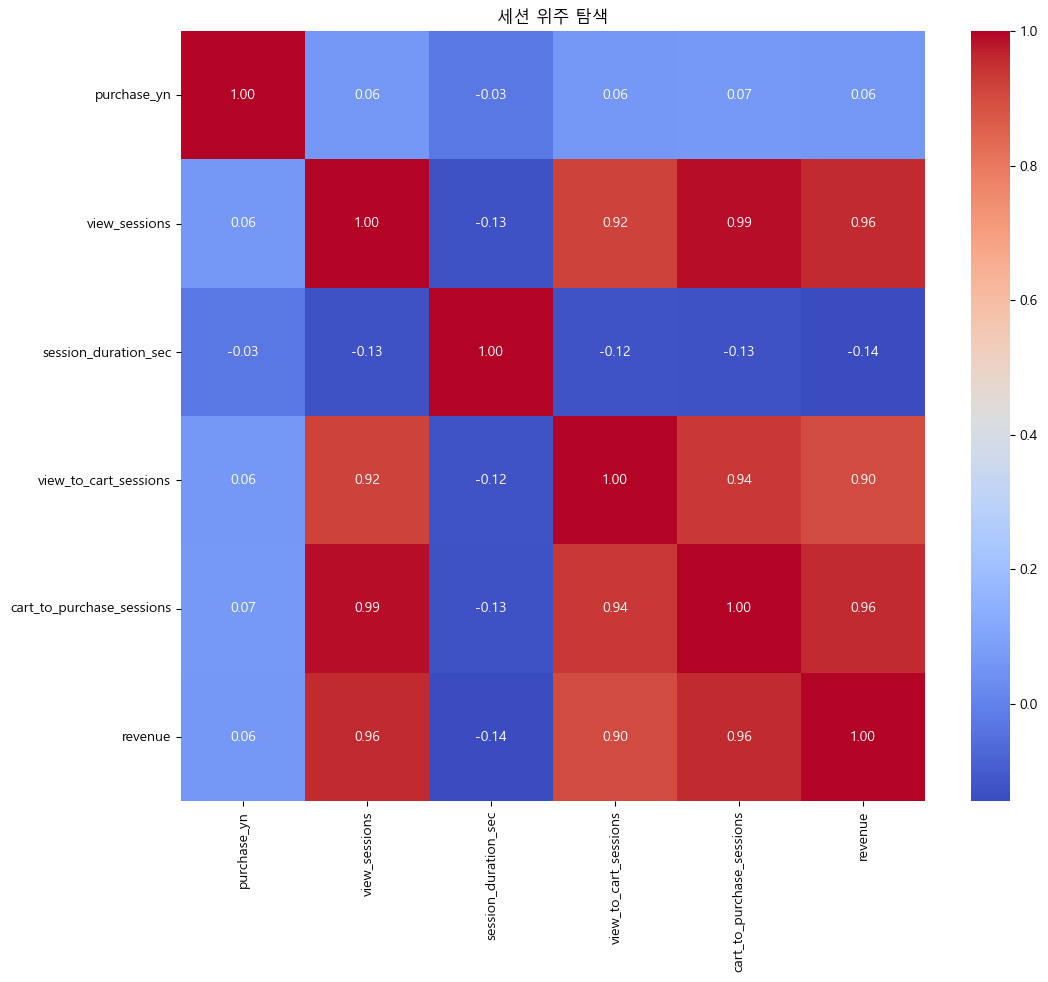

In [22]:
corr_cols = [
    'purchase_yn',
    'view_sessions', 'session_duration_sec', 'view_to_cart_sessions', 'cart_to_purchase_sessions',
    'revenue'
]
corr_data = df[corr_cols].corr(method='spearman')

print(corr_data)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('세션 위주 탐색')
plt.show()


### SQL / python으로 만든 전환율 지표가 세션 기준이라 (total_conversion_rate라던가)

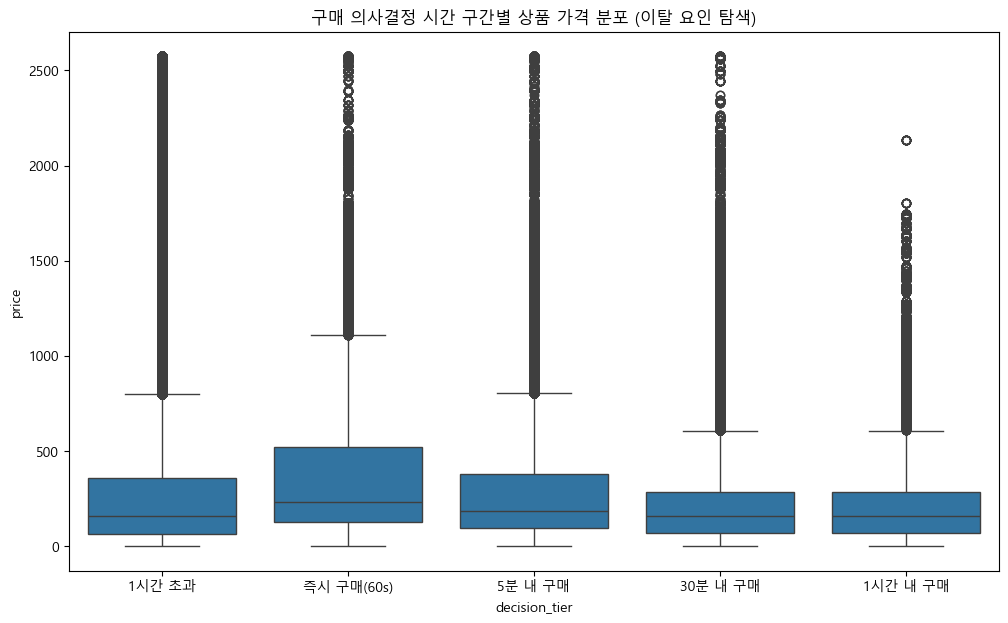

In [21]:
# 구매자 vs 비구매자(이탈자)
plt.figure(figsize=(12, 7))
sns.boxplot(x='decision_tier', y='price', data=df)
plt.title('구매 의사결정 시간 구간별 상품 가격 분포 (이탈 요인 탐색)')
plt.show()

In [ ]:
# !jupyter nbconvert --to markdown "은솔_퍼널분석_oct.ipynb"

[NbConvertApp] Converting notebook 은솔_퍼널분석_oct.ipynb to markdown
[NbConvertApp] Support files will be in 은솔_퍼널분석_oct_files\
[NbConvertApp] Making directory 은솔_퍼널분석_oct_files
[NbConvertApp] Writing 22305 bytes to 은솔_퍼널분석_oct.md


# 스마트폰

In [27]:
sm = df[df['category_code'] == 'electronics.smartphone'].copy()

ArrowMemoryError: malloc of size 805952384 failed

In [ ]:
del df
gc.collect()

10848

## 퍼널 분석 (2_sm)

- 메인 퍼널 전환 상관분석
- 단계별 병목 구간 특정 및 이탈 주요 영향 변수 탐색

In [ ]:
sm['funnel_stage'].unique()
sm['funnel_stage'].value_counts()

funnel_stage
view        38087676
purchase     2994996
cart         1335872
Name: count, dtype: int64

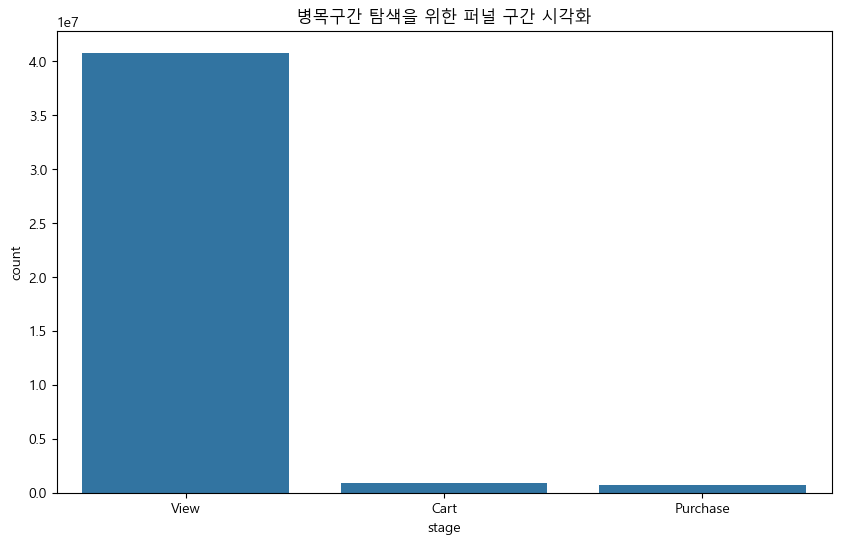

In [ ]:
# 전체 유저 중 몇명이 다음 구간으로 넘어갔는가 

# funnel 구간
funnel = sm[['view_yn', 'cart_yn', 'purchase_yn']].sum().reset_index()
funnel.columns = ['stage', 'count']
funnel['stage'] = ['View', 'Cart', 'Purchase']
funnel['cvr'] = (funnel['count'] / funnel['count'].shift(1) * 100).fillna(100)

plt.figure(figsize=(10, 6))
sns.barplot(data=funnel, x='stage', y='count')
plt.title('병목구간 탐색을 위한 퍼널 구간 시각화(sm)')
plt.show()

<Axes: >

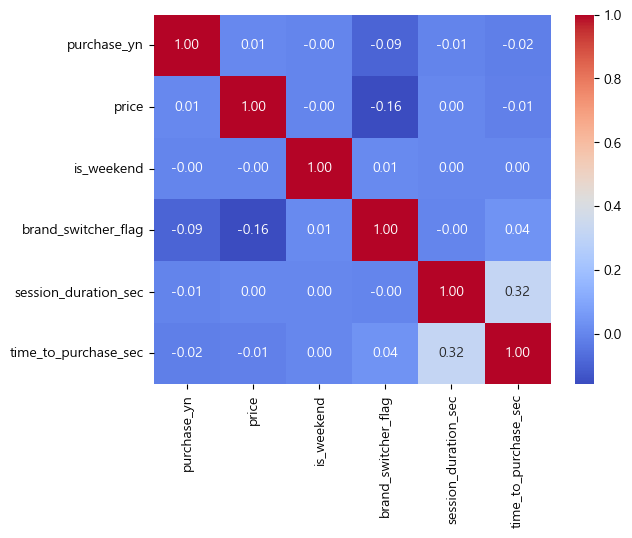

In [ ]:
# 유저행동들 (특징)
cols = ['purchase_yn', 'price', 'is_weekend', 'brand_switcher_flag', 'session_duration_sec', 'time_to_purchase_sec']
sns.heatmap(sm[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
# 상관분석 (유저 기준 -total_spend)
corr_col = ['total_spend', 'is_view', 'is_cart', 'is_weekend', 'is_purchase', 'purchase_count']

corr = sm[corr_col].corr()
print(corr)

                total_spend  is_view  is_cart  is_weekend  is_purchase  \
total_spend            1.00    -0.00     0.13       -0.00         0.20   
is_view               -0.00     1.00    -0.02       -0.00        -0.02   
is_cart                0.13    -0.02     1.00        0.01         0.50   
is_weekend            -0.00    -0.00     0.01        1.00         0.00   
is_purchase            0.20    -0.02     0.50        0.00         1.00   
purchase_count         0.08    -0.01     0.21       -0.00         0.14   

                purchase_count  
total_spend               0.08  
is_view                  -0.01  
is_cart                   0.21  
is_weekend               -0.00  
is_purchase               0.14  
purchase_count            1.00  


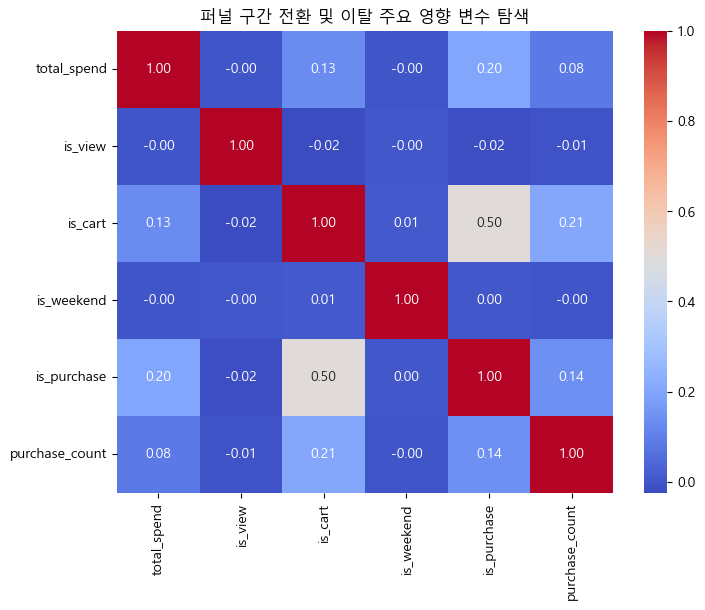

In [ ]:
# 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('퍼널 구간 전환 및 이탈 주요 영향 변수 탐색(sm)')
plt.show()

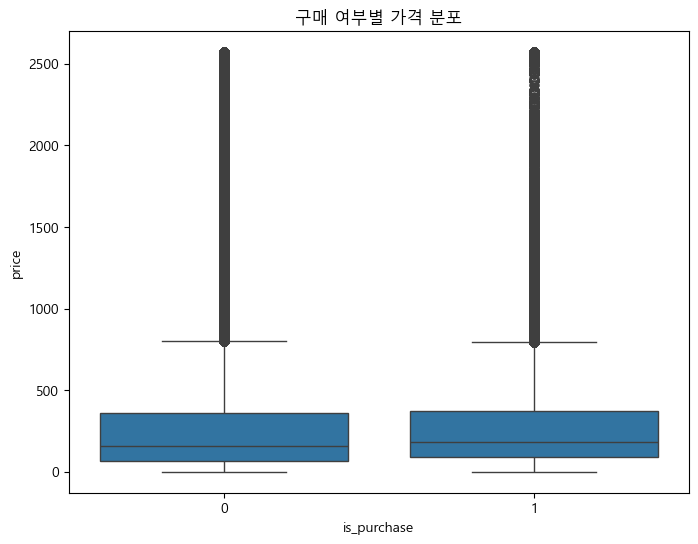

In [ ]:
# 가격 차이

plt.figure(figsize=(8, 6))
sns.boxplot(data=sm, x='is_purchase', y='price')
plt.title('구매 여부별 가격 분포(sm)')
plt.show()

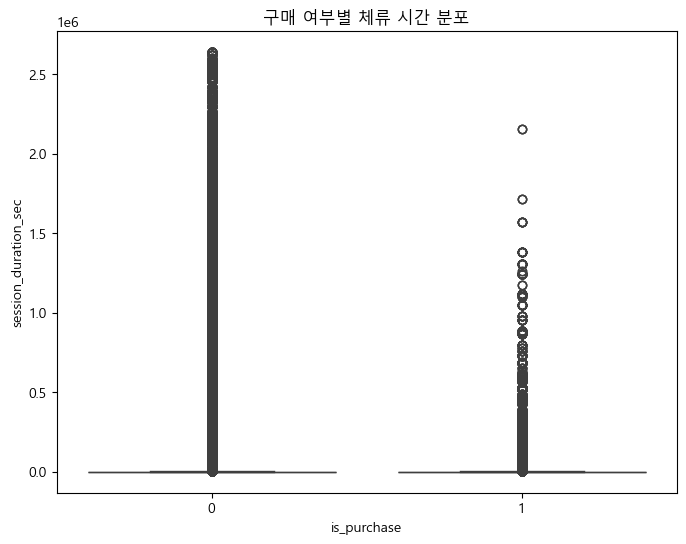

In [ ]:
# 체류시간

plt.figure(figsize=(8, 6))
sns.boxplot(data=sm, x='is_purchase', y='session_duration_sec')
plt.title('구매 여부별 체류 시간 분포(sm)')
plt.show()

In [ ]:
### SQL 데이터마트 파생변수 세부 탐색

                      purchase_yn  view_yn  cart_yn  price  hour  \
purchase_yn                  1.00    -0.67    -0.02   0.01 -0.02   
view_yn                     -0.67     1.00    -0.73  -0.02  0.03   
cart_yn                     -0.02    -0.73     1.00   0.02 -0.02   
price                        0.01    -0.02     0.02   1.00  0.02   
hour                        -0.02     0.03    -0.02   0.02  1.00   
time_to_purchase_sec        -0.02     0.02    -0.01  -0.01  0.00   
is_price_error_yn           -0.00    -0.00     0.00   0.67  0.01   
is_outlier_yn                0.07    -0.07     0.03   0.01 -0.00   

                      time_to_purchase_sec  is_price_error_yn  is_outlier_yn  
purchase_yn                          -0.02              -0.00           0.07  
view_yn                               0.02              -0.00          -0.07  
cart_yn                              -0.01               0.00           0.03  
price                                -0.01               0.67          

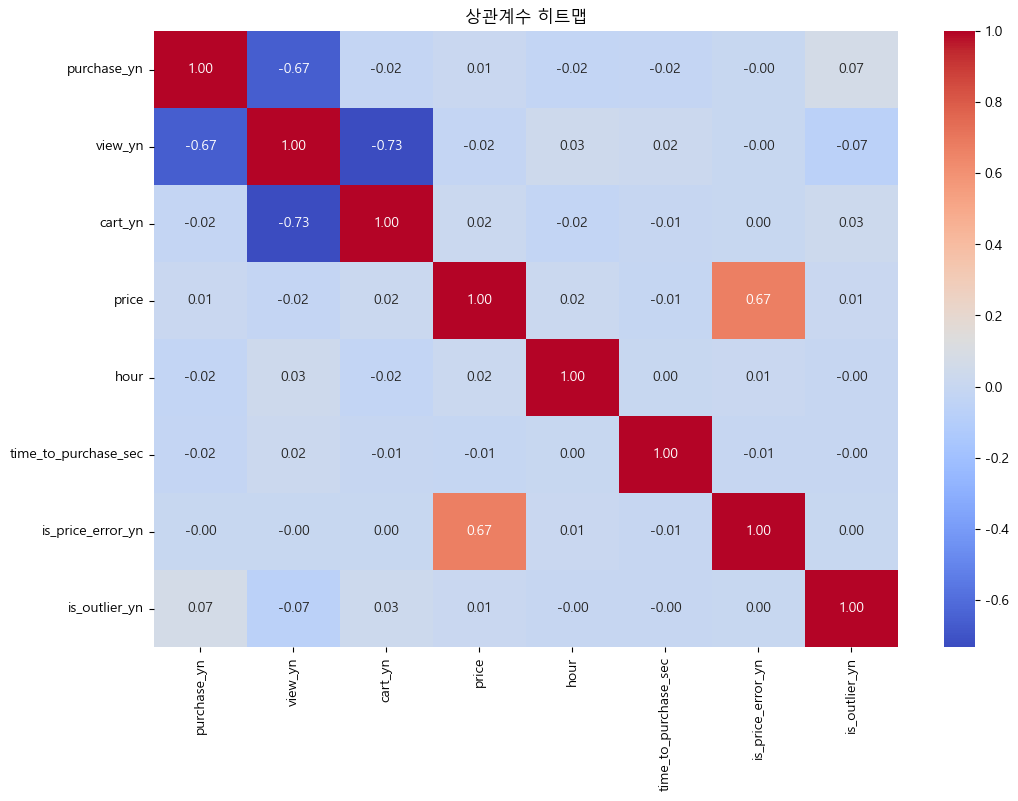

In [ ]:
# 수치형 변수만 추출
corr_cols = [
    'purchase_yn', 'view_yn', 'cart_yn', 'price', 
    'hour', 'time_to_purchase_sec',
    'is_price_error_yn', 'is_outlier_yn'
]
corr = sm[corr_cols].corr()
print(corr)

# 히트맵
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('상관계수 히트맵(sm)')
plt.show()

### decision_tier
- 구매 의사결정 시간 구간 분류(60초(1분)/5분/30분/1시간 기준)
- → ‘즉시 구매’의 세분화 

- consider_purchase_tier (즉시구매, 12, 24, 36, 36~)

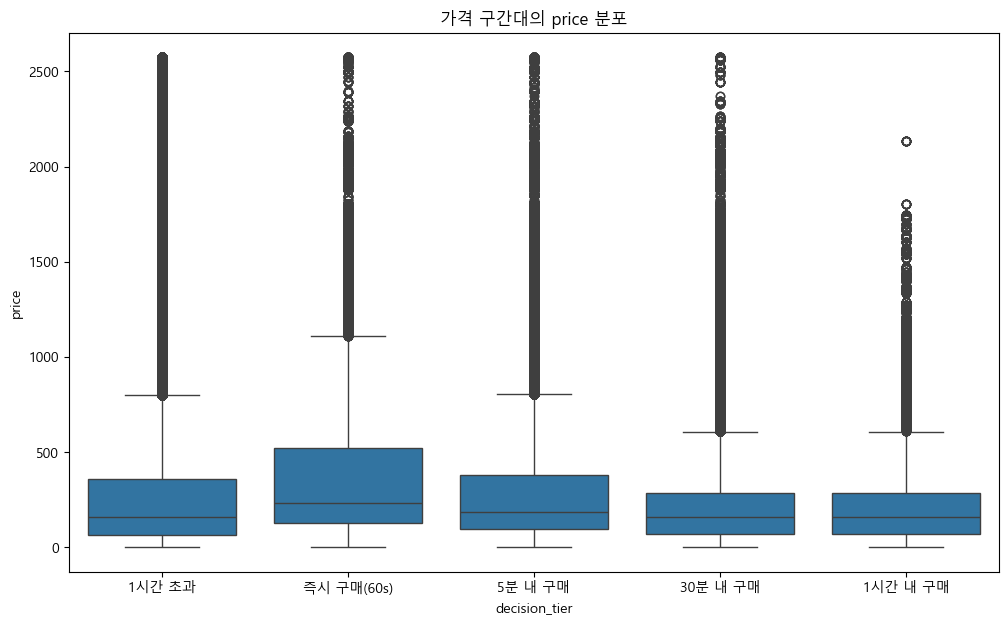

In [ ]:
# decision_tier별 price 분포
### 가격 구간대의 price 분포에 따라 구매 고려 시간에 영향이 있는가 (60초(1분)/5분/30분/1시간 기준)

plt.figure(figsize=(12, 7))
sns.boxplot(data=sm, x='decision_tier', y='price')
plt.title('가격 구간대의 price 분포(sm)')
plt.ylabel('price')
plt.xlabel('decision_tier')
plt.show()

## consider_purchase_tier이랑도 보고 싶은데 그건 태블로로 보는 게 더 빠를 것 같다

### 병목 구간 세부 탐색(근거)

                      purchase_yn  price  brand_switcher_flag  \
purchase_yn                  1.00   0.01                -0.09   
price                        0.01   1.00                -0.16   
brand_switcher_flag         -0.09  -0.16                 1.00   
session_duration_sec        -0.01   0.00                -0.00   
time_to_purchase_sec        -0.02  -0.01                 0.04   

                      session_duration_sec  time_to_purchase_sec  
purchase_yn                          -0.01                 -0.02  
price                                 0.00                 -0.01  
brand_switcher_flag                  -0.00                  0.04  
session_duration_sec                  1.00                  0.32  
time_to_purchase_sec                  0.32                  1.00  


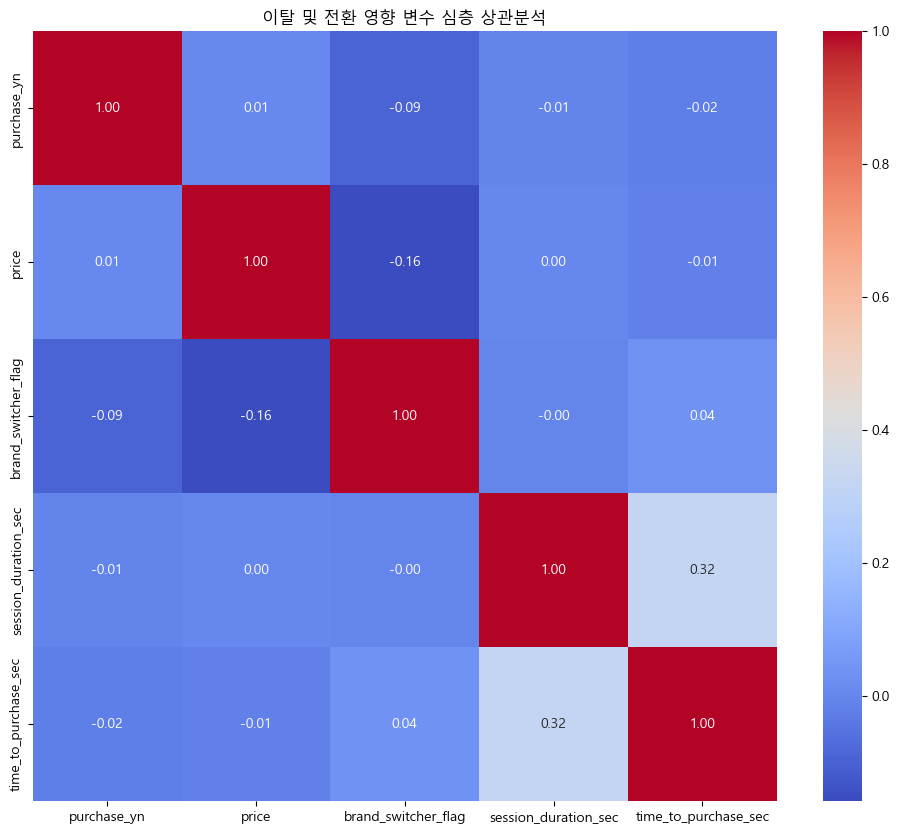

In [ ]:
# 이탈 및 전환 주요 영향 변수 상관분석
corr_cols = [
    'purchase_yn', 'price', 
    'brand_switcher_flag', 'session_duration_sec',
    'time_to_purchase_sec' # v -> p 고민 시간
]
corr_data = sm[corr_cols].corr()

print(corr_data)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('이탈 및 전환 영향 변수 심층 상관분석(sm)')
plt.show()


### SQL / python으로 만든 전환율 지표가 세션 기준이라 (total_conversion_rate라던가)

                           purchase_yn  view_sessions  session_duration_sec  \
purchase_yn                       1.00           0.06                 -0.03   
view_sessions                     0.06           1.00                 -0.13   
session_duration_sec             -0.03          -0.13                  1.00   
view_to_cart_sessions             0.06           0.92                 -0.12   
cart_to_purchase_sessions         0.07           0.99                 -0.13   
revenue                           0.06           0.96                 -0.14   

                           view_to_cart_sessions  cart_to_purchase_sessions  \
purchase_yn                                 0.06                       0.07   
view_sessions                               0.92                       0.99   
session_duration_sec                       -0.12                      -0.13   
view_to_cart_sessions                       1.00                       0.94   
cart_to_purchase_sessions                   0.94   

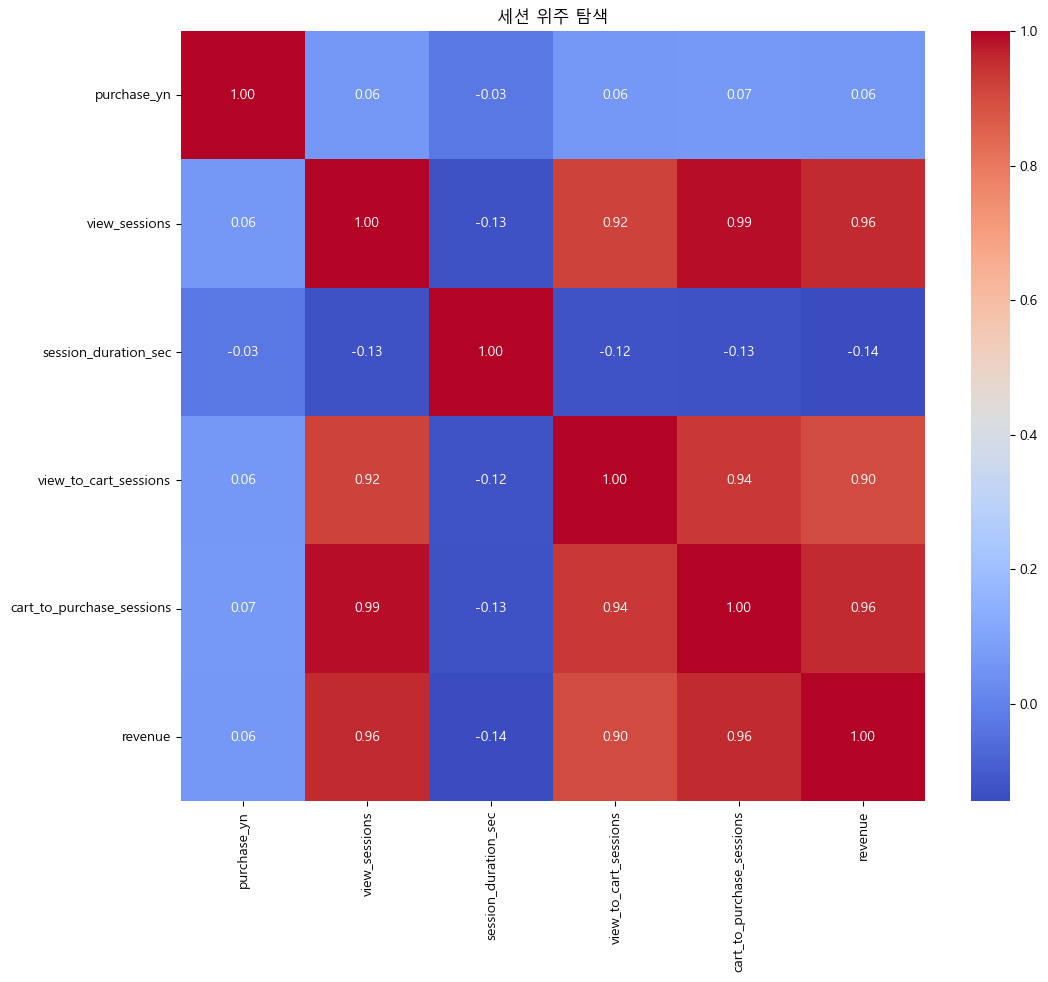

In [ ]:
corr_cols = [
    'purchase_yn',
    'view_sessions', 'session_duration_sec', 'view_to_cart_sessions', 'cart_to_purchase_sessions',
    'revenue'
]
corr_data = sm[corr_cols].corr(method='spearman')

print(corr_data)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('세션 위주 탐색(sm)')
plt.show()


### SQL / python으로 만든 전환율 지표가 세션 기준이라 (total_conversion_rate라던가)

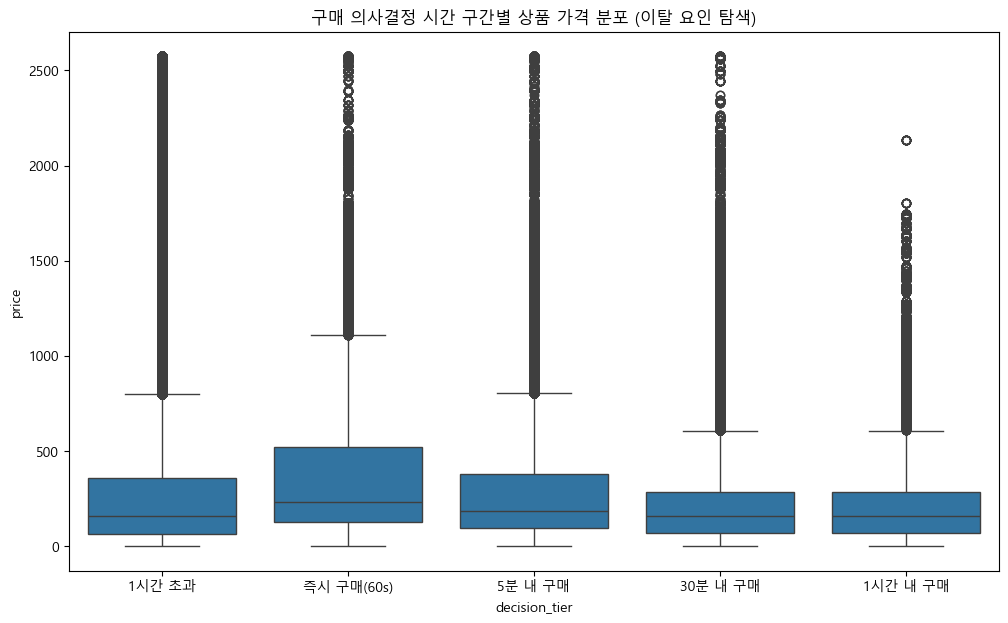

In [ ]:
# 구매자 vs 비구매자(이탈자)
plt.figure(figsize=(12, 7))
sns.boxplot(x='decision_tier', y='price', data=sm)
plt.title('구매 의사결정 시간 구간별 상품 가격 분포 (이탈 요인 탐색, sm)')
plt.show()

In [ ]:
!jupyter nbconvert --to markdown "은솔_퍼널분석_oct.ipynb"

[NbConvertApp] Converting notebook 은솔_퍼널분석_oct.ipynb to markdown
[NbConvertApp] Support files will be in 은솔_퍼널분석_oct_files\
[NbConvertApp] Making directory 은솔_퍼널분석_oct_files
[NbConvertApp] Writing 22305 bytes to 은솔_퍼널분석_oct.md
